Zadanie 1.
1.1.Import modułów (należy zaimportować klasę LogisticRegression z biblioteki
sklearn.linear_model).
1.2. Otwarcie pliku z danymi (titanic_train.csv). Należy zaimportować nazwy kolumn
i stworzyć obiekt df.
1.3. Sprawdzenie podstawowych statystyk.
1.4. Sprawdzenie kompletności danych.

In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

In [3]:
titanic_df = pd.read_csv('titanic_train.csv')

print(titanic_df.head())
print(titanic_df.describe())
print(titanic_df.info())

missing_data = titanic_df.isnull().sum()
print("Liczba brakujących wartości w każdej kolumnie:")
print(missing_data)




   PassengerId  Survived  Pclass   
0            1         0       3  \
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp   
0                            Braund, Mr. Owen Harris    male  22.0      1  \
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

1.5. Wizualizacja:
1.5.1. Podział liczby osób ze względu na przetrwanie katastrofy,
1.5.2. Podział przeżycia osób względem płci,
1.5.3. Podział przeżycia osób, względem klasy biletów,
1.5.4. Podział pasażerów ze względu na wiek,
1.5.5. Podział pasażerów ze względu liczbę współpasażerów z rodziny,
1.5.6. Podział biletów ze względu na cenę.

C:\Users\Garland\AppData\Local\Temp\ipykernel_17680\1790072566.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=titanic_df, palette='Set1')


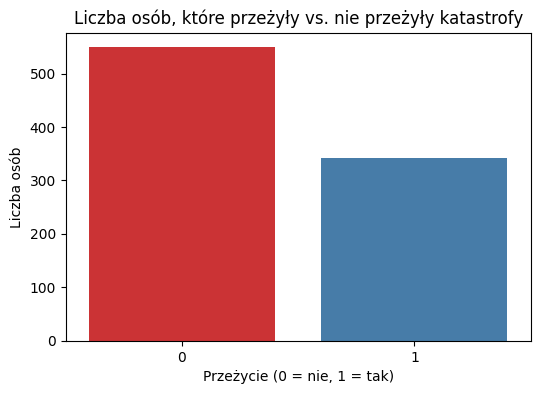

In [4]:
# Podział osób ze względu na przetrwanie katastrofy
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=titanic_df, palette='Set1')
plt.title('Liczba osób, które przeżyły vs. nie przeżyły katastrofy')
plt.xlabel('Przeżycie (0 = nie, 1 = tak)')
plt.ylabel('Liczba osób')
plt.show()


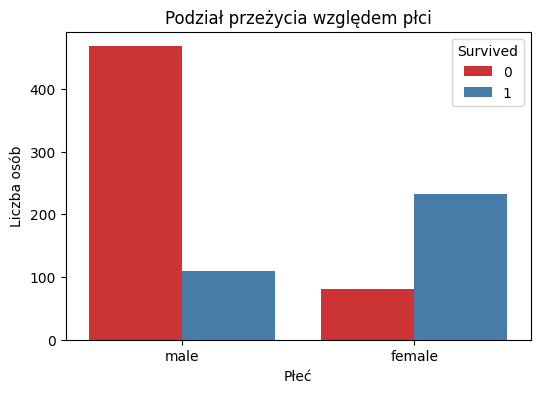

In [5]:
# Podział przeżycia osób względem płci
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=titanic_df, palette='Set1')
plt.title('Podział przeżycia względem płci')
plt.xlabel('Płeć')
plt.ylabel('Liczba osób')
plt.show()


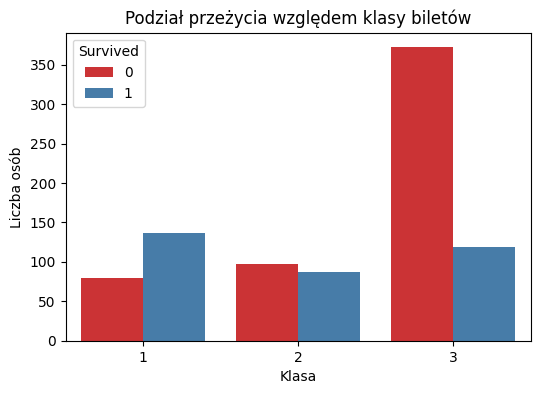

In [6]:
# Podział przeżycia osób względem klasy biletów
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', hue='Survived', data=titanic_df, palette='Set1')
plt.title('Podział przeżycia względem klasy biletów')
plt.xlabel('Klasa')
plt.ylabel('Liczba osób')
plt.show()


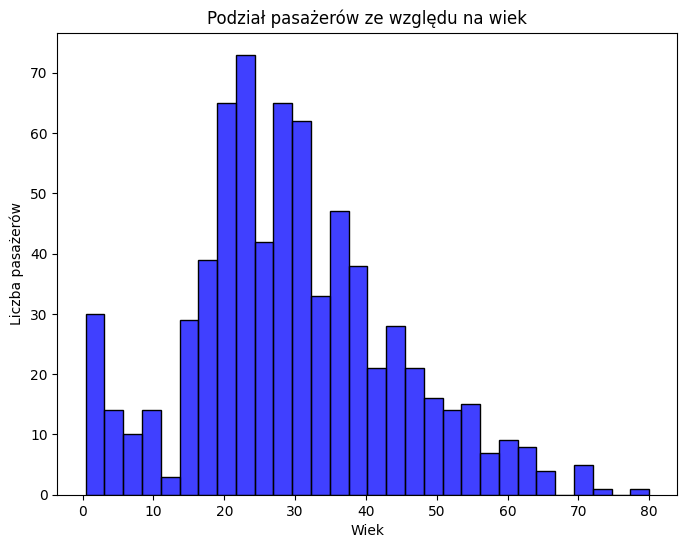

In [7]:
# Podział pasażerów ze względu na wiek
plt.figure(figsize=(8, 6))
sns.histplot(titanic_df['Age'].dropna(), bins=30, kde=False, color='blue')
plt.title('Podział pasażerów ze względu na wiek')
plt.xlabel('Wiek')
plt.ylabel('Liczba pasażerów')
plt.show()


C:\Users\Garland\AppData\Local\Temp\ipykernel_17680\2742261618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TotalFamily', data=titanic_df, palette='Set2')


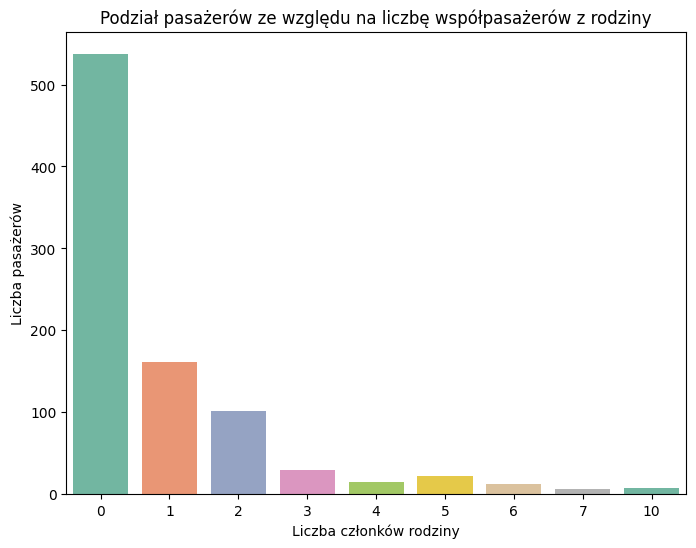

In [12]:
# Podział pasażerów ze względu na liczbę współpasażerów z rodziny (SibSp + Parch)
titanic_df['TotalFamily'] = titanic_df['SibSp'] + titanic_df['Parch']
plt.figure(figsize=(8, 6))
sns.countplot(x='TotalFamily', data=titanic_df, palette='Set2')
plt.title('Podział pasażerów ze względu na liczbę współpasażerów z rodziny')
plt.xlabel('Liczba członków rodziny')
plt.ylabel('Liczba pasażerów')
plt.show()


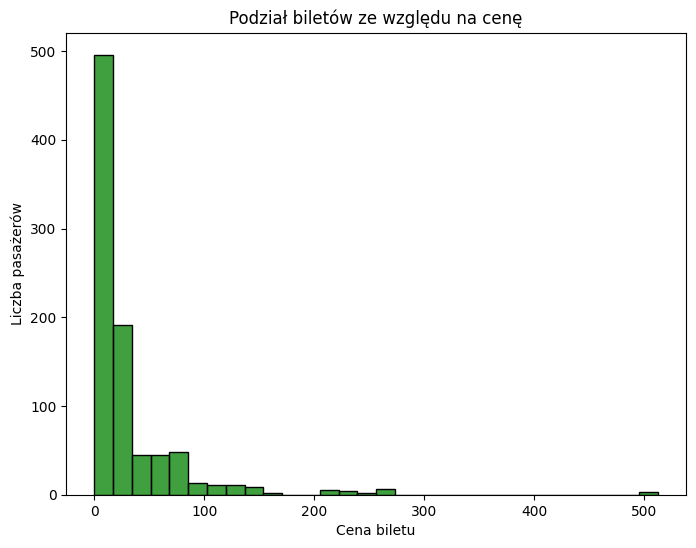

In [13]:
# Podział biletów ze względu na cenę
plt.figure(figsize=(8, 6))
sns.histplot(titanic_df['Fare'], bins=30, kde=False, color='green')
plt.title('Podział biletów ze względu na cenę')
plt.xlabel('Cena biletu')
plt.ylabel('Liczba pasażerów')
plt.show()


2. Przygotowanie danych:
2.1. Sprawdzenie brakujących danych.
2.2. Wizualizacja:
2.2.1. Heatmapa ze względu na liczbę brakujących danych.

In [14]:
missing_data = titanic_df.isnull().sum()
print("Liczba brakujących wartości w każdej kolumnie:")
print(missing_data)


Liczba brakujących wartości w każdej kolumnie:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
TotalFamily      0
dtype: int64


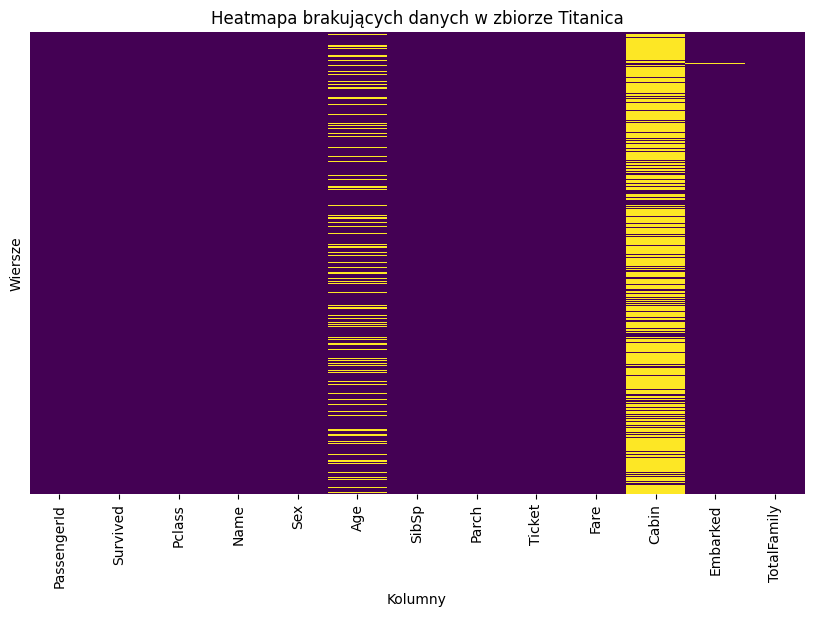

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(titanic_df.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title('Heatmapa brakujących danych w zbiorze Titanica')
plt.xlabel('Kolumny')
plt.ylabel('Wiersze')
plt.show()


2.3. Data Cleaning:
2.3.1. Age - trzeba uzupełnić brakujące dane;
2.3.2. Cabin - usunąć kolumnę (usunięcie całego atrybutu);
2.3.3. Embarked - usunąć wiersz NaN.

In [16]:
median_age = titanic_df['Age'].median()
titanic_df['Age'].fillna(median_age, inplace=True)

In [17]:
titanic_df.drop(columns=['Cabin'], inplace=True)

In [18]:
titanic_df.dropna(subset=['Embarked'], inplace=True)

2.4. Przekształcenie danych kategorialnych:
2.4.1. Dummying: płeć i miejsce wejścia na pokład.
2.4.2. Usunięcie kolumn 'Sex', 'Embarked', 'Name', 'Ticket' z danych.
2.4.3. Stworzenie obiektu df_titanic z przetworzonych danych treningowych + zmienna
dotycząca płci + zmienna dotycząca embark.
2.4.4. Usunięcie kolumny 'PassengerId'.

In [19]:
titanic_df = pd.get_dummies(titanic_df, columns=['Sex', 'Embarked'], drop_first=True)

titanic_df.drop(columns=['Name', 'Ticket'], inplace=True)

df_titanic = titanic_df.copy()

df_titanic.drop(columns=['PassengerId'], inplace=True)

print(df_titanic.head())


   Survived  Pclass   Age  SibSp  Parch     Fare  TotalFamily  Sex_male   
0         0       3  22.0      1      0   7.2500            1      True  \
1         1       1  38.0      1      0  71.2833            1     False   
2         1       3  26.0      0      0   7.9250            0     False   
3         1       1  35.0      1      0  53.1000            1     False   
4         0       3  35.0      0      0   8.0500            0      True   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


3. Podział zbioru danych na treningowy i testowy:
3.1. Do zmiennej X należy zapisać wszystkie kolumny z zestawu danych df_titanic (macierz
cech) oprócz kolumny Survived (można skorzystać z metody drop z argumentem axis=1).
3.2. Do zmiennej y należy zapisać dane z kolumny Survived.
3.3. Do zmiennych X_train, X_test, y_train, y_test należy zapisać dane powstałe z podziału
X i y na dane uczące i testowe (z biblioteki sklearn.model_selection należy zaimportować
train_test_split). Zbiór testowy ma stanowić 20% zbioru danych, a random_state = 101.

In [21]:
X = df_titanic.drop(columns=['Survived'], axis=1)

y = df_titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

print(f"Rozmiar zbioru treningowego: {X_train.shape[0]} próbek")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]} próbek")


Rozmiar zbioru treningowego: 711 próbek
Rozmiar zbioru testowego: 178 próbek


4. Wybór modelu:
Należy stworzyć obiekt regresji logistycznej lr_model. Dla obiektu lr_model należy wywołać
metodę fit(), która ma nauczyć model w jaki sposób odgadywać, czy dany pasażer statku Titanic
przeżył katastrofę.

In [22]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

Model regresji logistycznej został wytreningowany.


c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


5. Wykorzystanie wytrenowanego modelu do prognozowania wyników dla nowych
przypadków. W zmiennej y_pred należy zapisać wynik predykcji dla X_test.

In [23]:
y_pred = lr_model.predict(X_test)

Wyniki prognozowania dla zbioru testowego:
[0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 1 1 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0
 0 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]


6. Ewaluacja modelu:
6.1. Ewaluacja modelu za pomocą raportu z klasyfikacji oraz macierzy błędów (z biblioteki
sklearn.metrics należy zaimportować odpowiednie wskaźniki wydajności).
6.2. Krzywa ROC.
6.3. Krzywa czułość/precyzja.

In [25]:
print("Raport z klasyfikacji:")
print(classification_report(y_test, y_pred))

confusion = confusion_matrix(y_test, y_pred)
print("Macierz błędów:")
print(confusion)

Raport z klasyfikacji:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       107
           1       0.85      0.66      0.75        71

    accuracy                           0.82       178
   macro avg       0.83      0.79      0.80       178
weighted avg       0.82      0.82      0.82       178

Macierz błędów:
[[99  8]
 [24 47]]


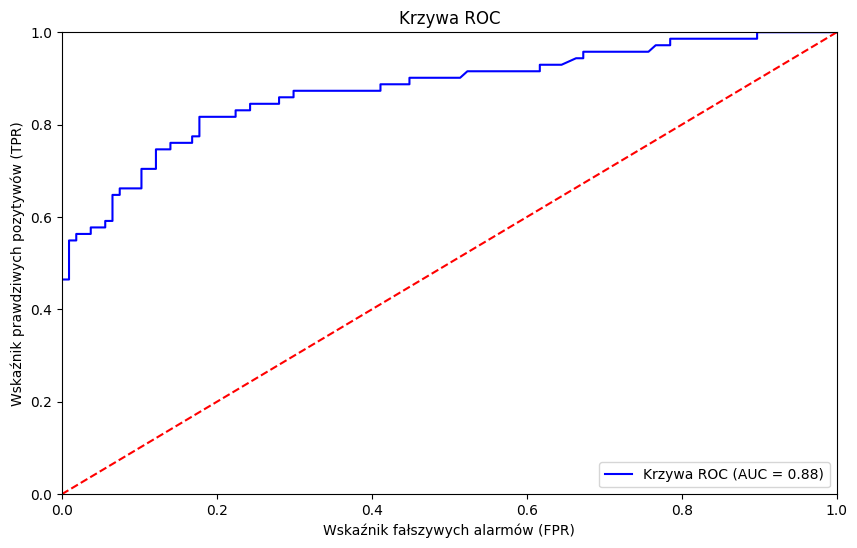

In [26]:
y_prob = lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label='Krzywa ROC (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('Wskaźnik fałszywych alarmów (FPR)')
plt.ylabel('Wskaźnik prawdziwych pozytywów (TPR)')
plt.title('Krzywa ROC')
plt.legend(loc='lower right')
plt.show()

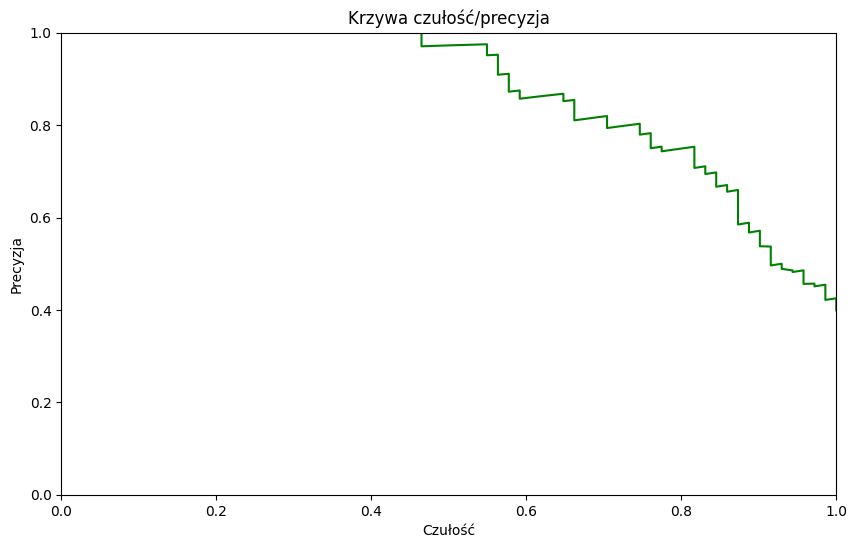

In [27]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='green')
plt.xlabel('Czułość')
plt.ylabel('Precyzja')
plt.title('Krzywa czułość/precyzja')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.show()